# imports e requesitos

In [1]:
! pip install ultralytics
! pip install opencv-python
! pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from IPython.display import Image, display

# Carregando dataset e treinando modelo

In [5]:
torch.cuda.empty_cache()

# Isso vai imprimir quanto de memória a placa tem livre agora.
print(f"Memória Alocada: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Memória Livre: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Memória Alocada: 0.00 GB
Memória Livre: 0.00 GB


In [6]:
CAMINHO_DO_DATASET = "Recyclable.v1i.yolov8/data.yaml"

# Carrega os pesos iniciais do YOLOv10-Nano
model = YOLO("yolov10n.pt")

# treinamento estruturado
results_train = model.train(
    data=CAMINHO_DO_DATASET,
    project="Automacao_Triagem",  # Pasta raiz dos experimentos
    name="yolov10n_esteira",  # Subpasta deste treinamento específico
    epochs=100, # Número de épocas para treinamento
    batch=16,  # Ajustado para otimização de memória
    imgsz=640, # Tamanho da imagem de entrada
    device="cuda", # Usa GPU se disponível
    amp=True,  # Ativa precisão mista automática
)

Ultralytics 8.4.56  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Recyclable.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10n_esteira-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

# Inferência no conjunto de teste

In [8]:
# Carrega o melhor modelo gerado no treinamento anterior
melhor_modelo_path = "runs/detect/Automacao_Triagem/yolov10n_esteira/weights/best.pt"
model_treinado = YOLO(melhor_modelo_path)

# Conjunto de teste
pasta_imagens_teste = "Recyclable.v1i.yolov8/test/images"

# Fazendo a inferência e salvando as imagens com as bounding boxes desenhadas
predicoes = model_treinado.predict(
    source=pasta_imagens_teste,
    conf=0.25, # valor de confiança mínimo para considerar uma detecção válida
    save=True,  # Salva as imagens com as bounding boxes desenhadas
    project="Automacao_Triagem",
    name="resultados_teste_visual",
)

print(
    f"Inferência concluída! As imagens com as caixas foram salvas em: {predicoes[0].save_dir}"
)


image 1/50 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\Recyclable.v1i.yolov8\test\images\metal1005_jpg.rf.37c84297d39fd95f3505f89025e5cf82.jpg: 640x640 1 PLASTIC, 8.8ms
image 2/50 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\Recyclable.v1i.yolov8\test\images\metal1014_jpeg.rf.5c2e8df2b34cd600be02d79b177e707b.jpg: 640x640 1 PLASTIC, 13.8ms
image 3/50 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\Recyclable.v1i.yolov8\test\images\metal1021_jpg.rf.52ed14fcc4034c72cdb831d96cdda894.jpg: 640x640 1 GLASS, 2 PLASTICs, 14.1ms
image 4/50 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\Recyclable.v1i.yolov8\test\images\metal1043_jpg.rf.90358f01804394ee03f3bd28061e7f3e.jpg: 640x640 1 GLASS, 1 PLASTIC, 13.1ms
image 5/50 c:\Users\Guilherme\Desktop\VI

# Visualização no conjunto de testes

Total de imagens encontradas para exibição: 50


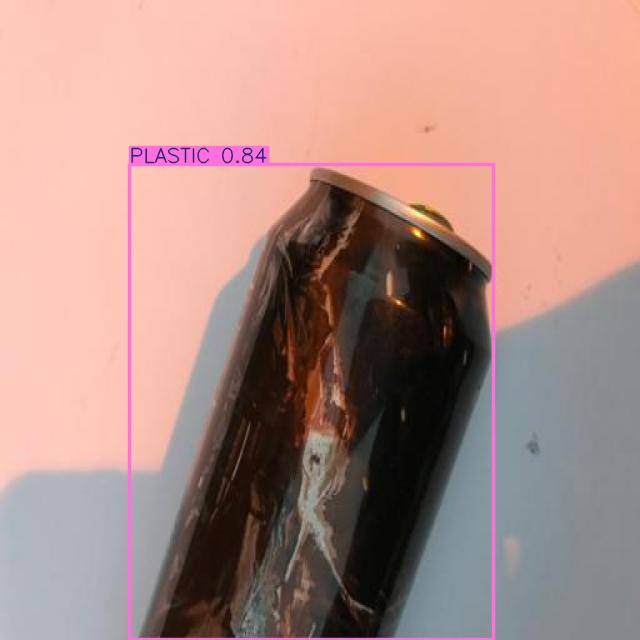

--------------------------------------------------------------------------------



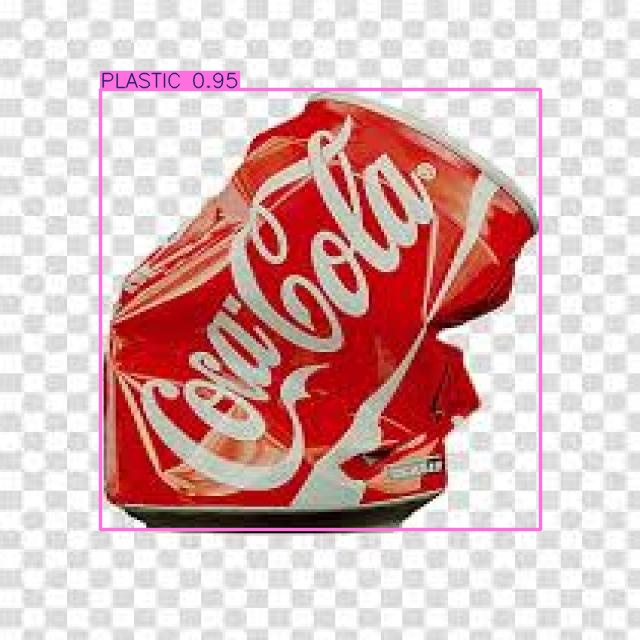

--------------------------------------------------------------------------------



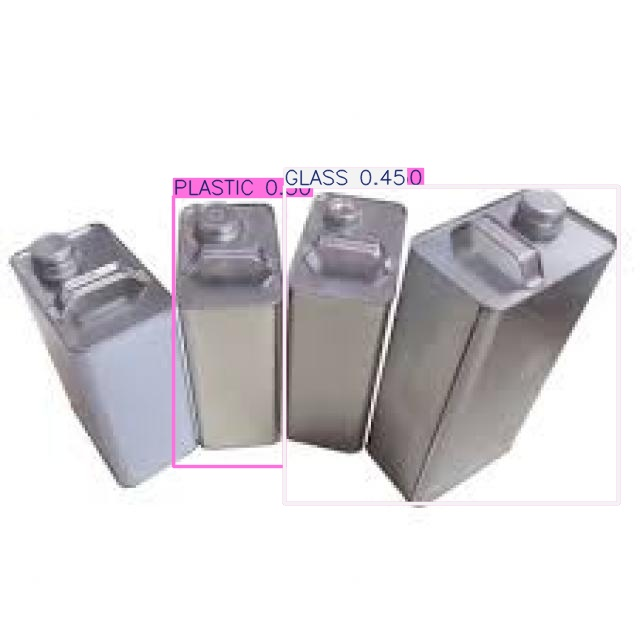

--------------------------------------------------------------------------------



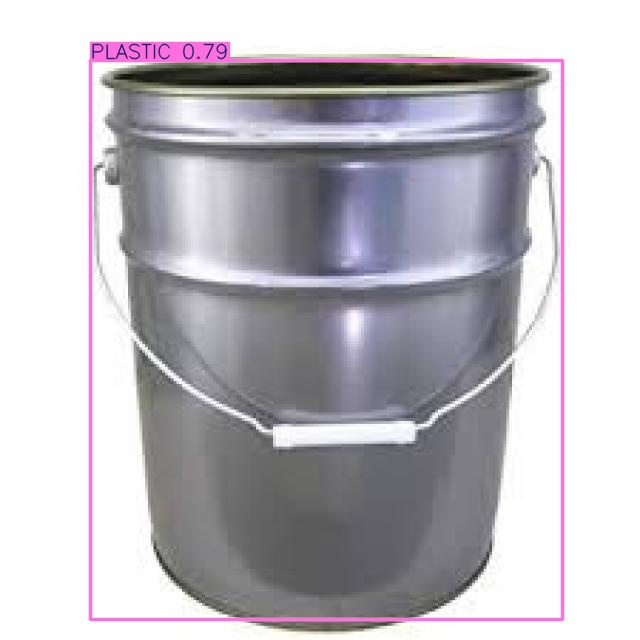

--------------------------------------------------------------------------------



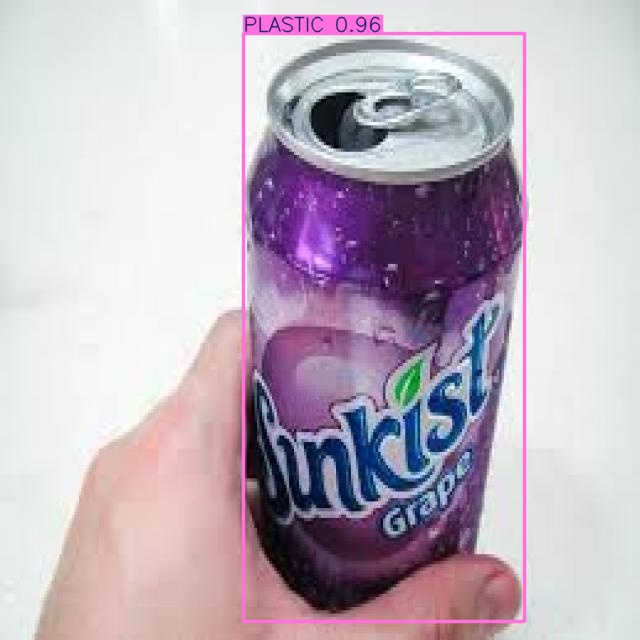

--------------------------------------------------------------------------------



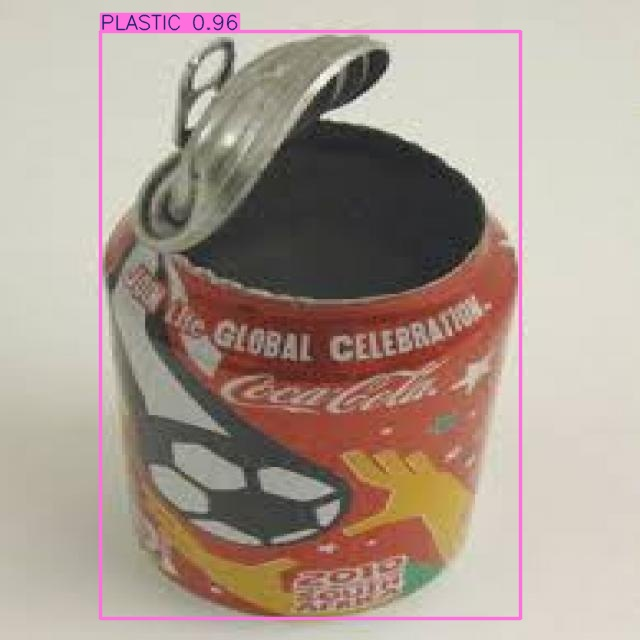

--------------------------------------------------------------------------------



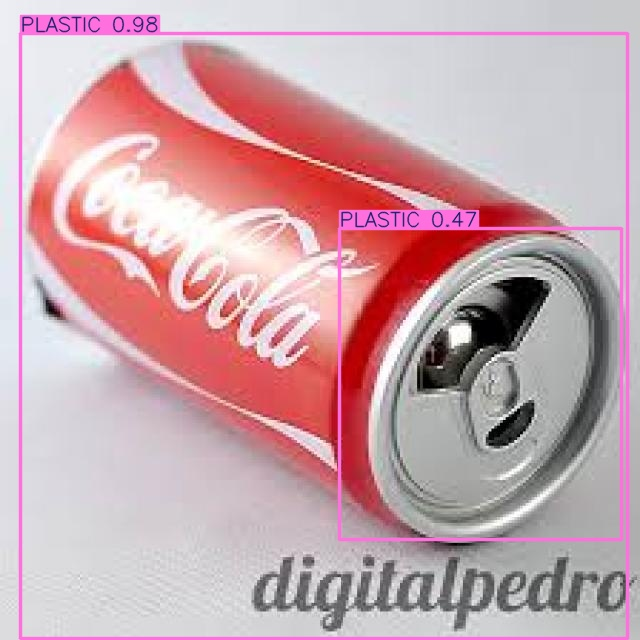

--------------------------------------------------------------------------------



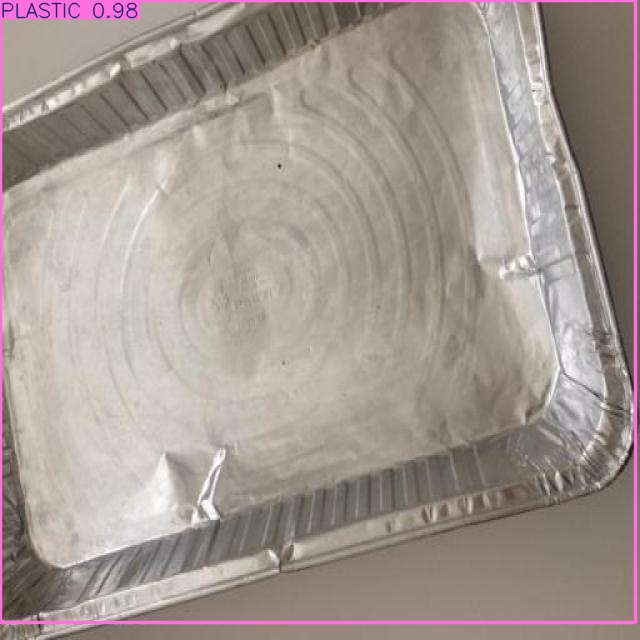

--------------------------------------------------------------------------------



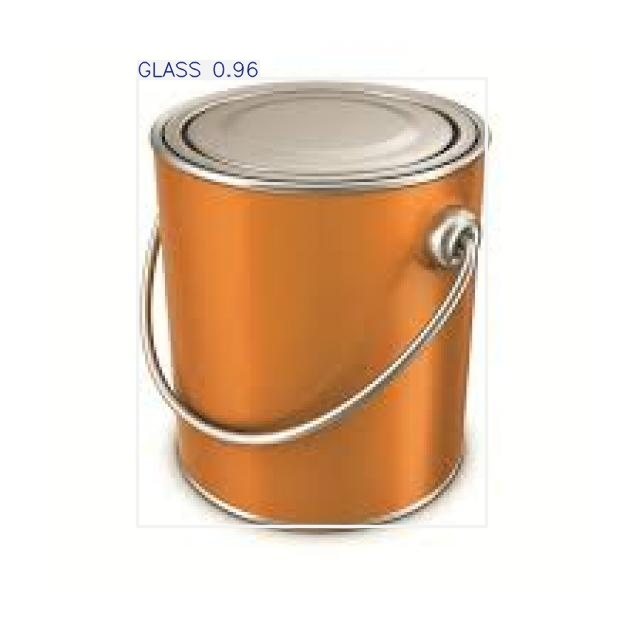

--------------------------------------------------------------------------------



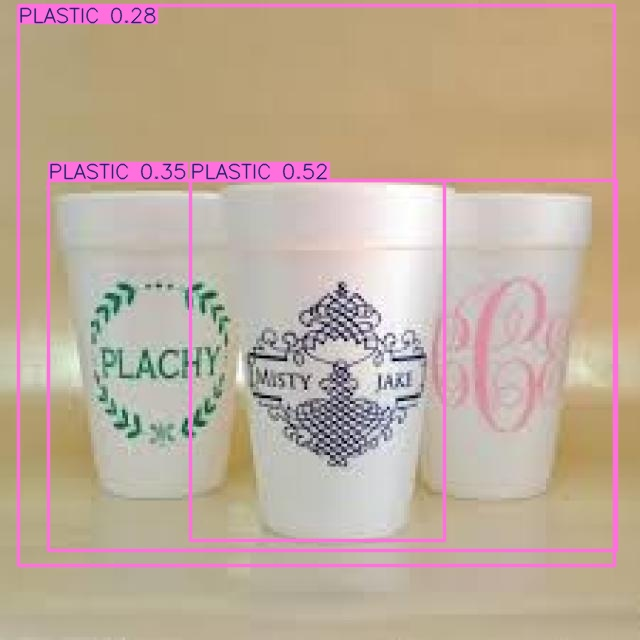

--------------------------------------------------------------------------------



In [17]:
diretorio_saida = predicoes[0].save_dir

# Busca por todas as imagens processadas (colocando as extenssões mais comuns)
imagens_processadas = glob.glob(os.path.join(diretorio_saida, "*.jpg")) + \
                      glob.glob(os.path.join(diretorio_saida, "*.png")) + \
                      glob.glob(os.path.join(diretorio_saida, "*.jpeg")) 

print(f"Total de imagens encontradas para exibição: {len(imagens_processadas)}")

#  Define a quantidade máxima de imagens que deseja exibir na tela para evitar travamentos
limite_exibicao = 10

# Plotagem utilizando Matplotlib
for i, caminho_img in enumerate(imagens_processadas[:limite_exibicao]):
    display(Image(filename=caminho_img, width=400))
    print("-" * 80 + "\n")

# Métricas finais

Foram encontradas 8 imagens de métricas e distribuições.

Gráfico: Boxf1 Curve


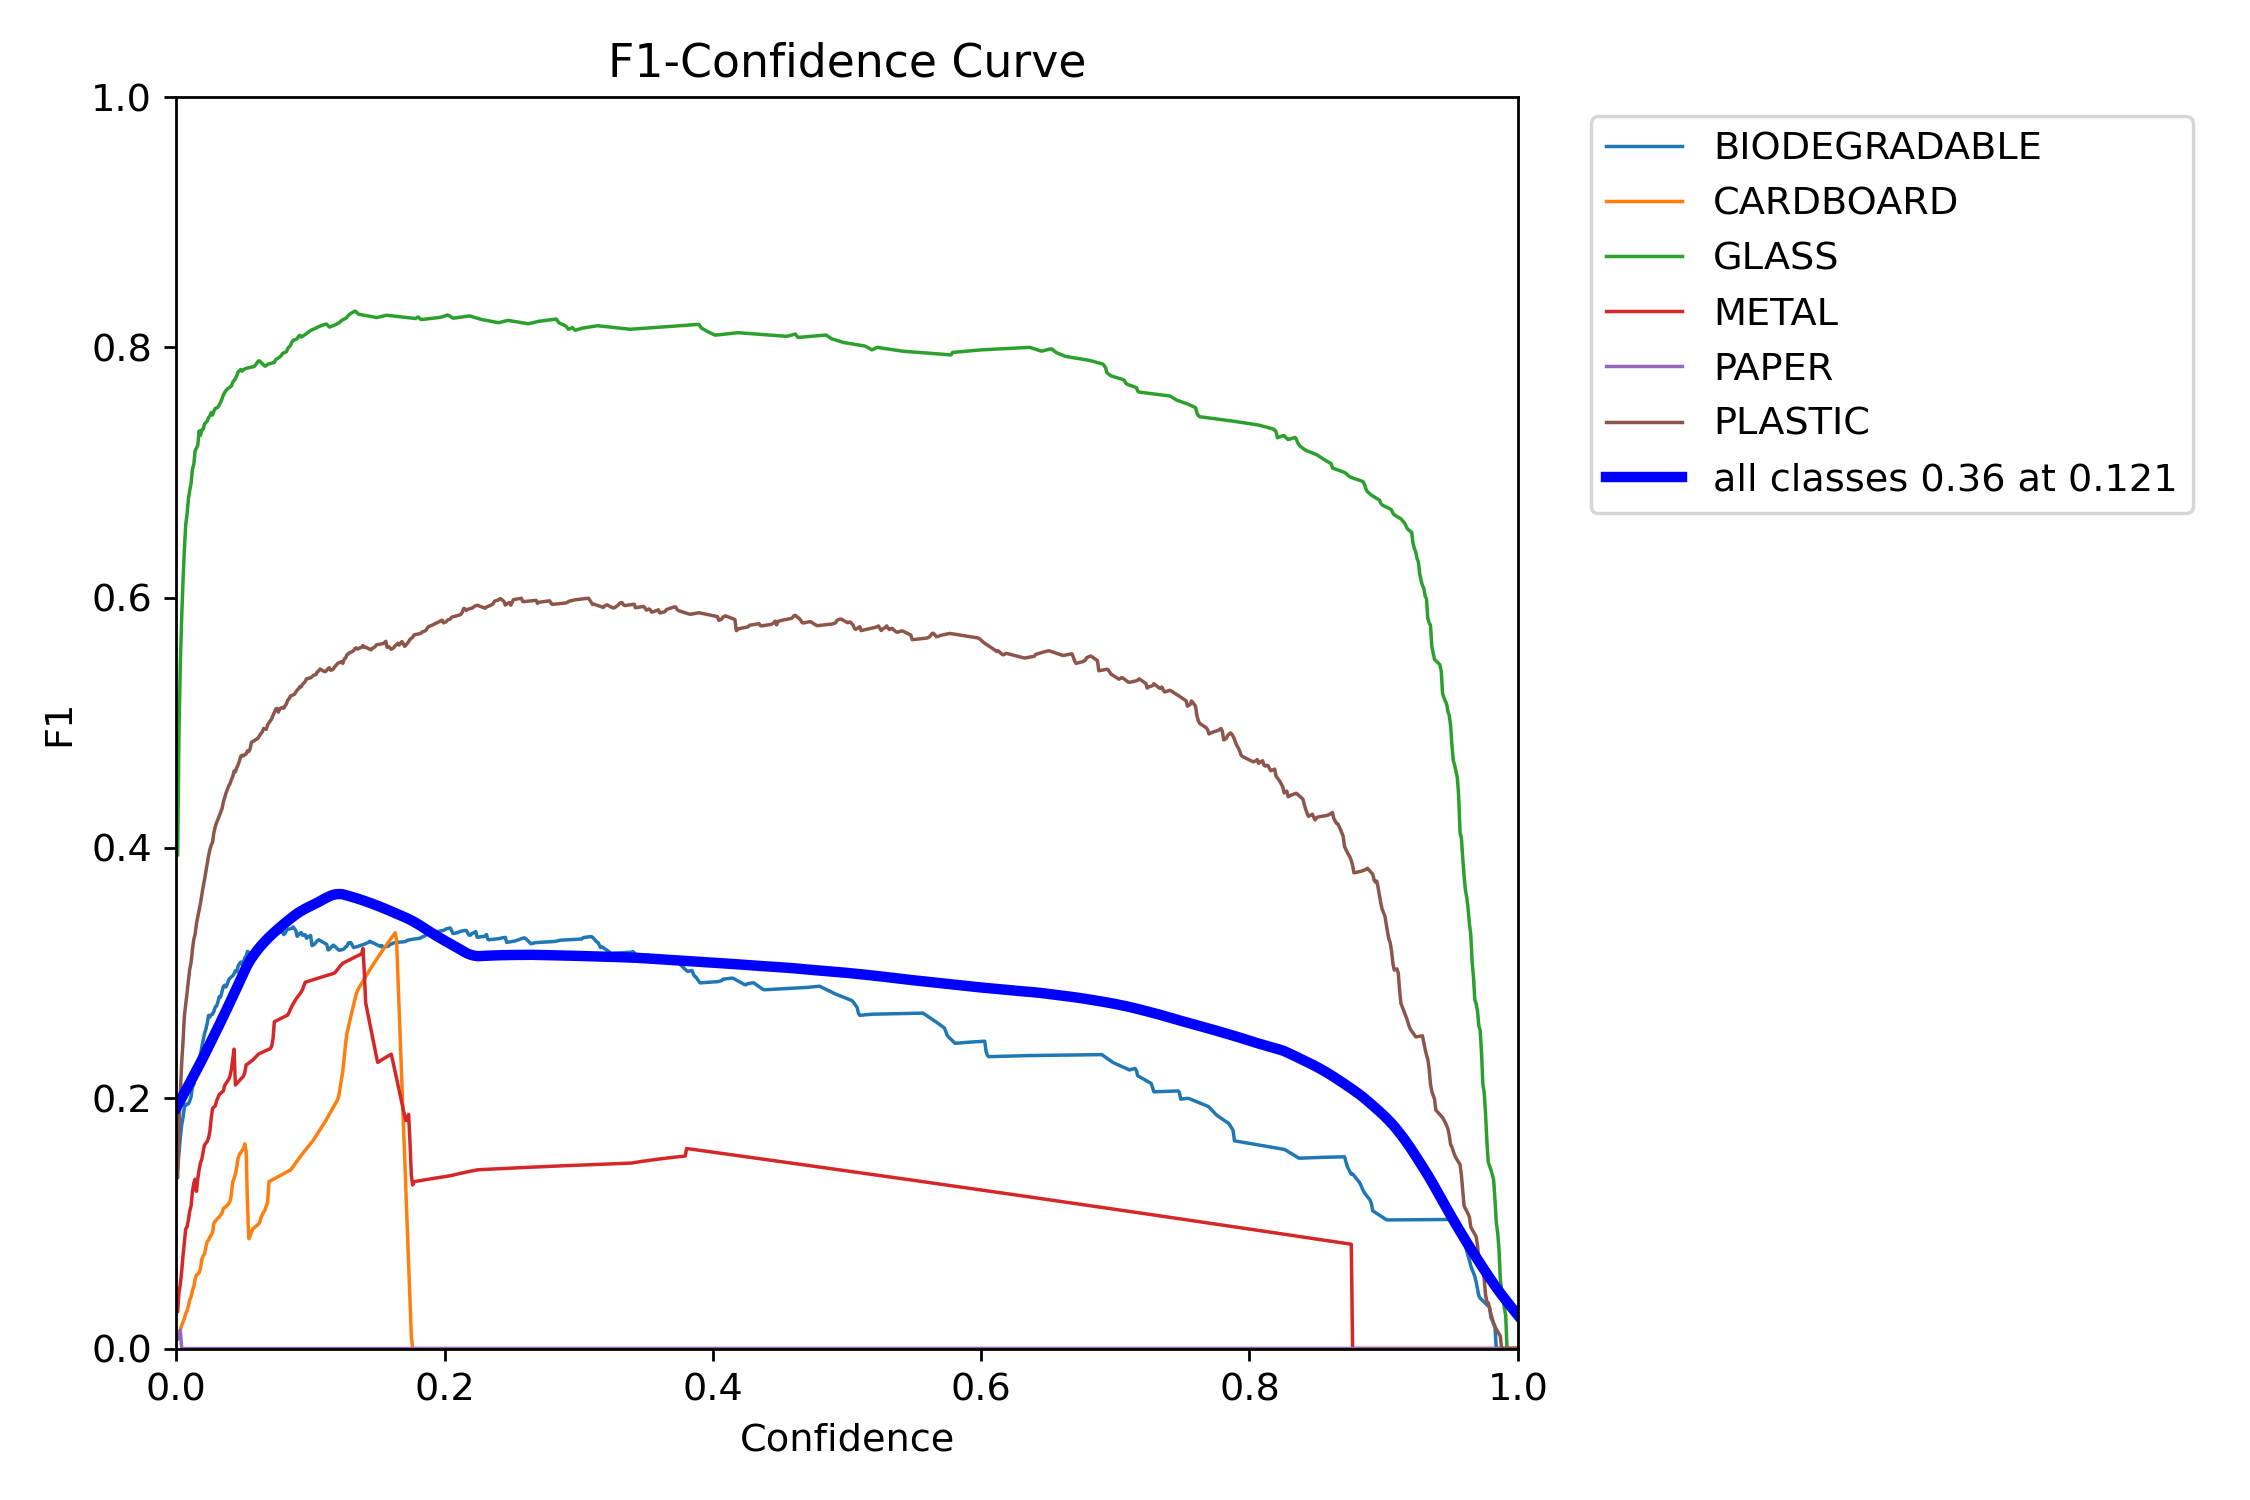

--------------------------------------------------------------------------------

Gráfico: Boxpr Curve


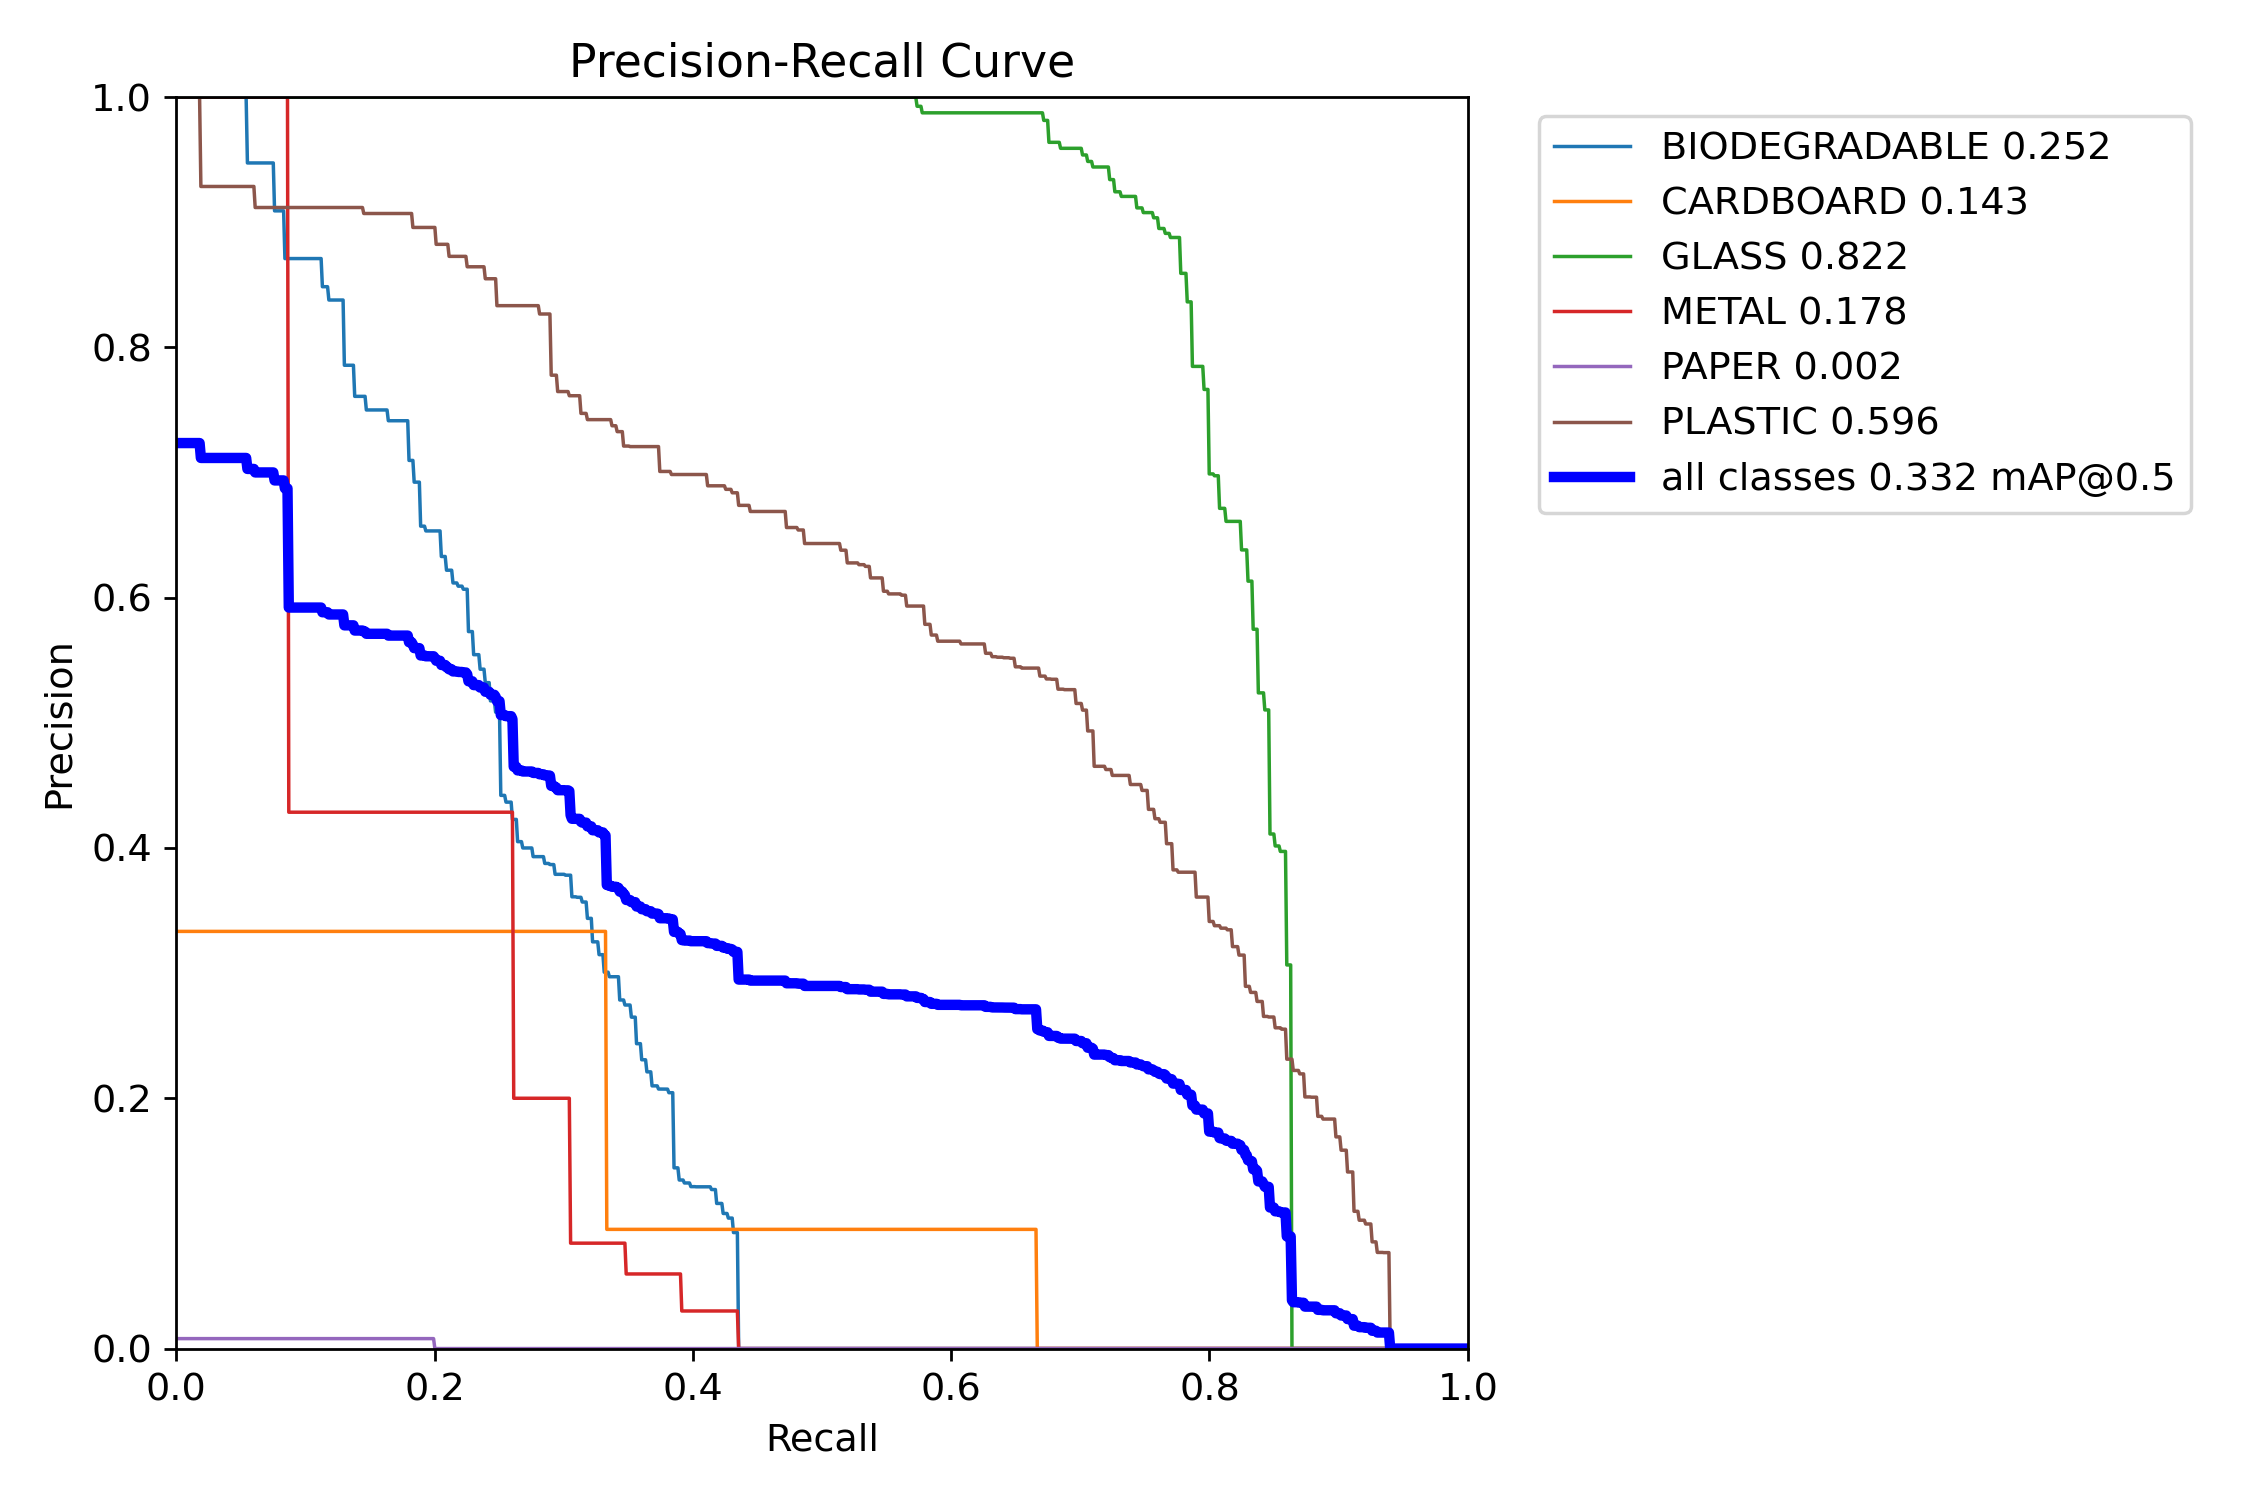

--------------------------------------------------------------------------------

Gráfico: Boxp Curve


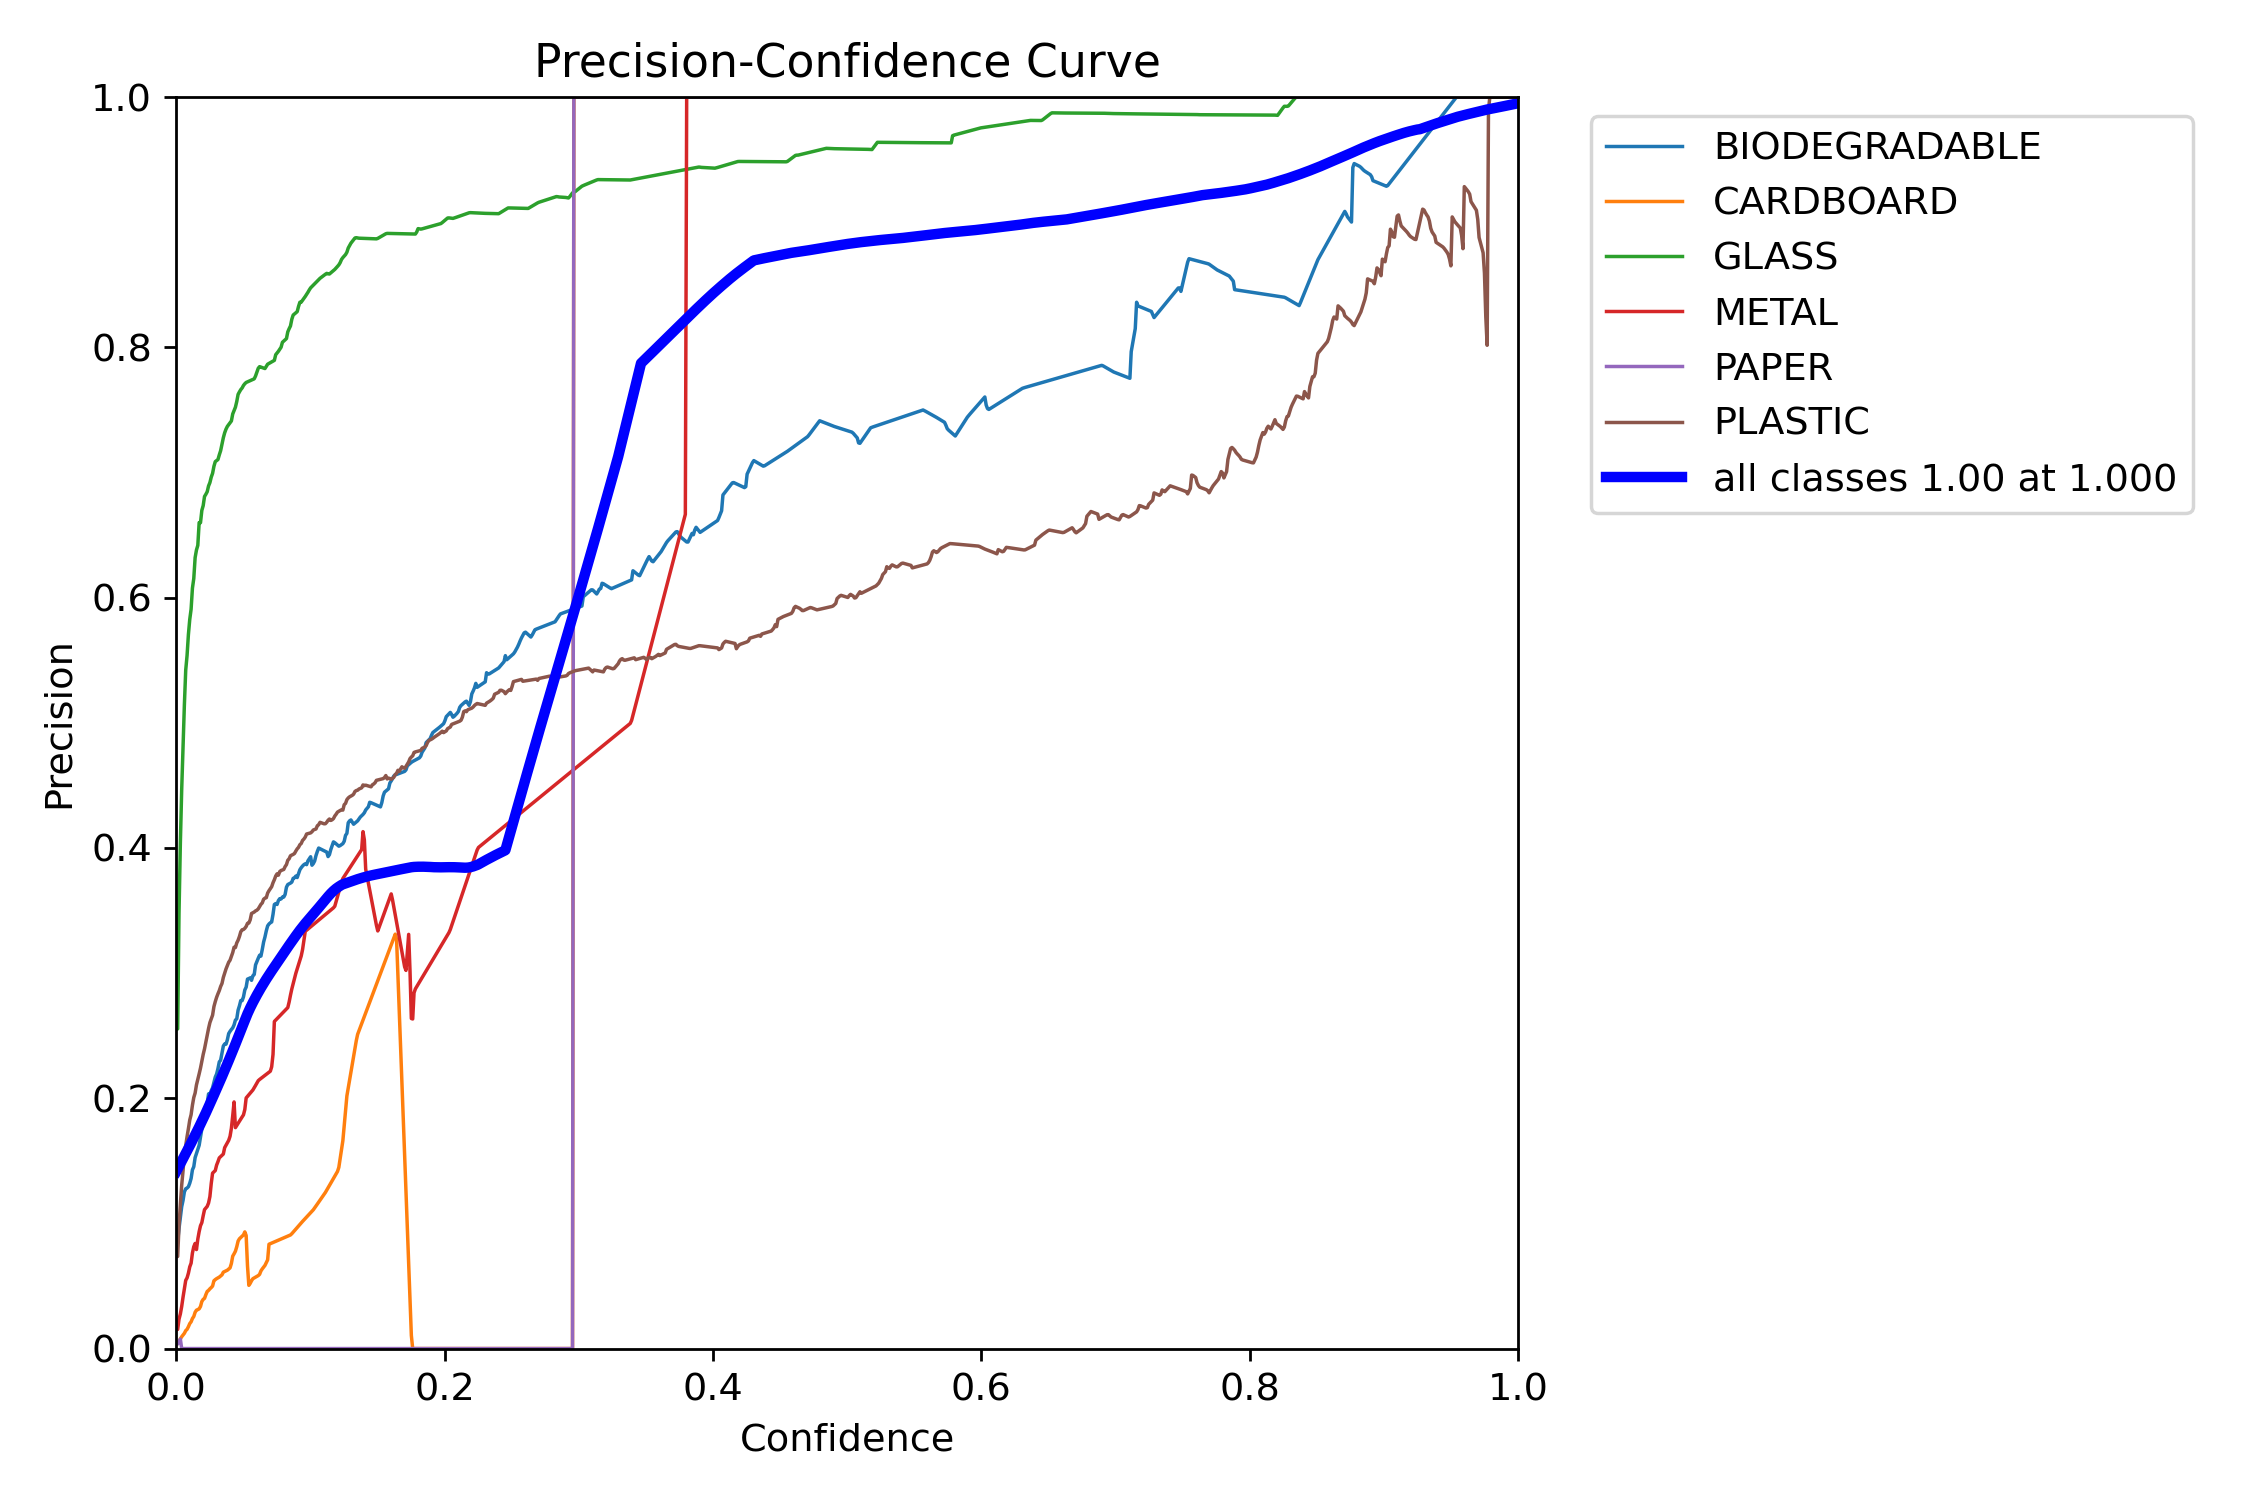

--------------------------------------------------------------------------------

Gráfico: Boxr Curve


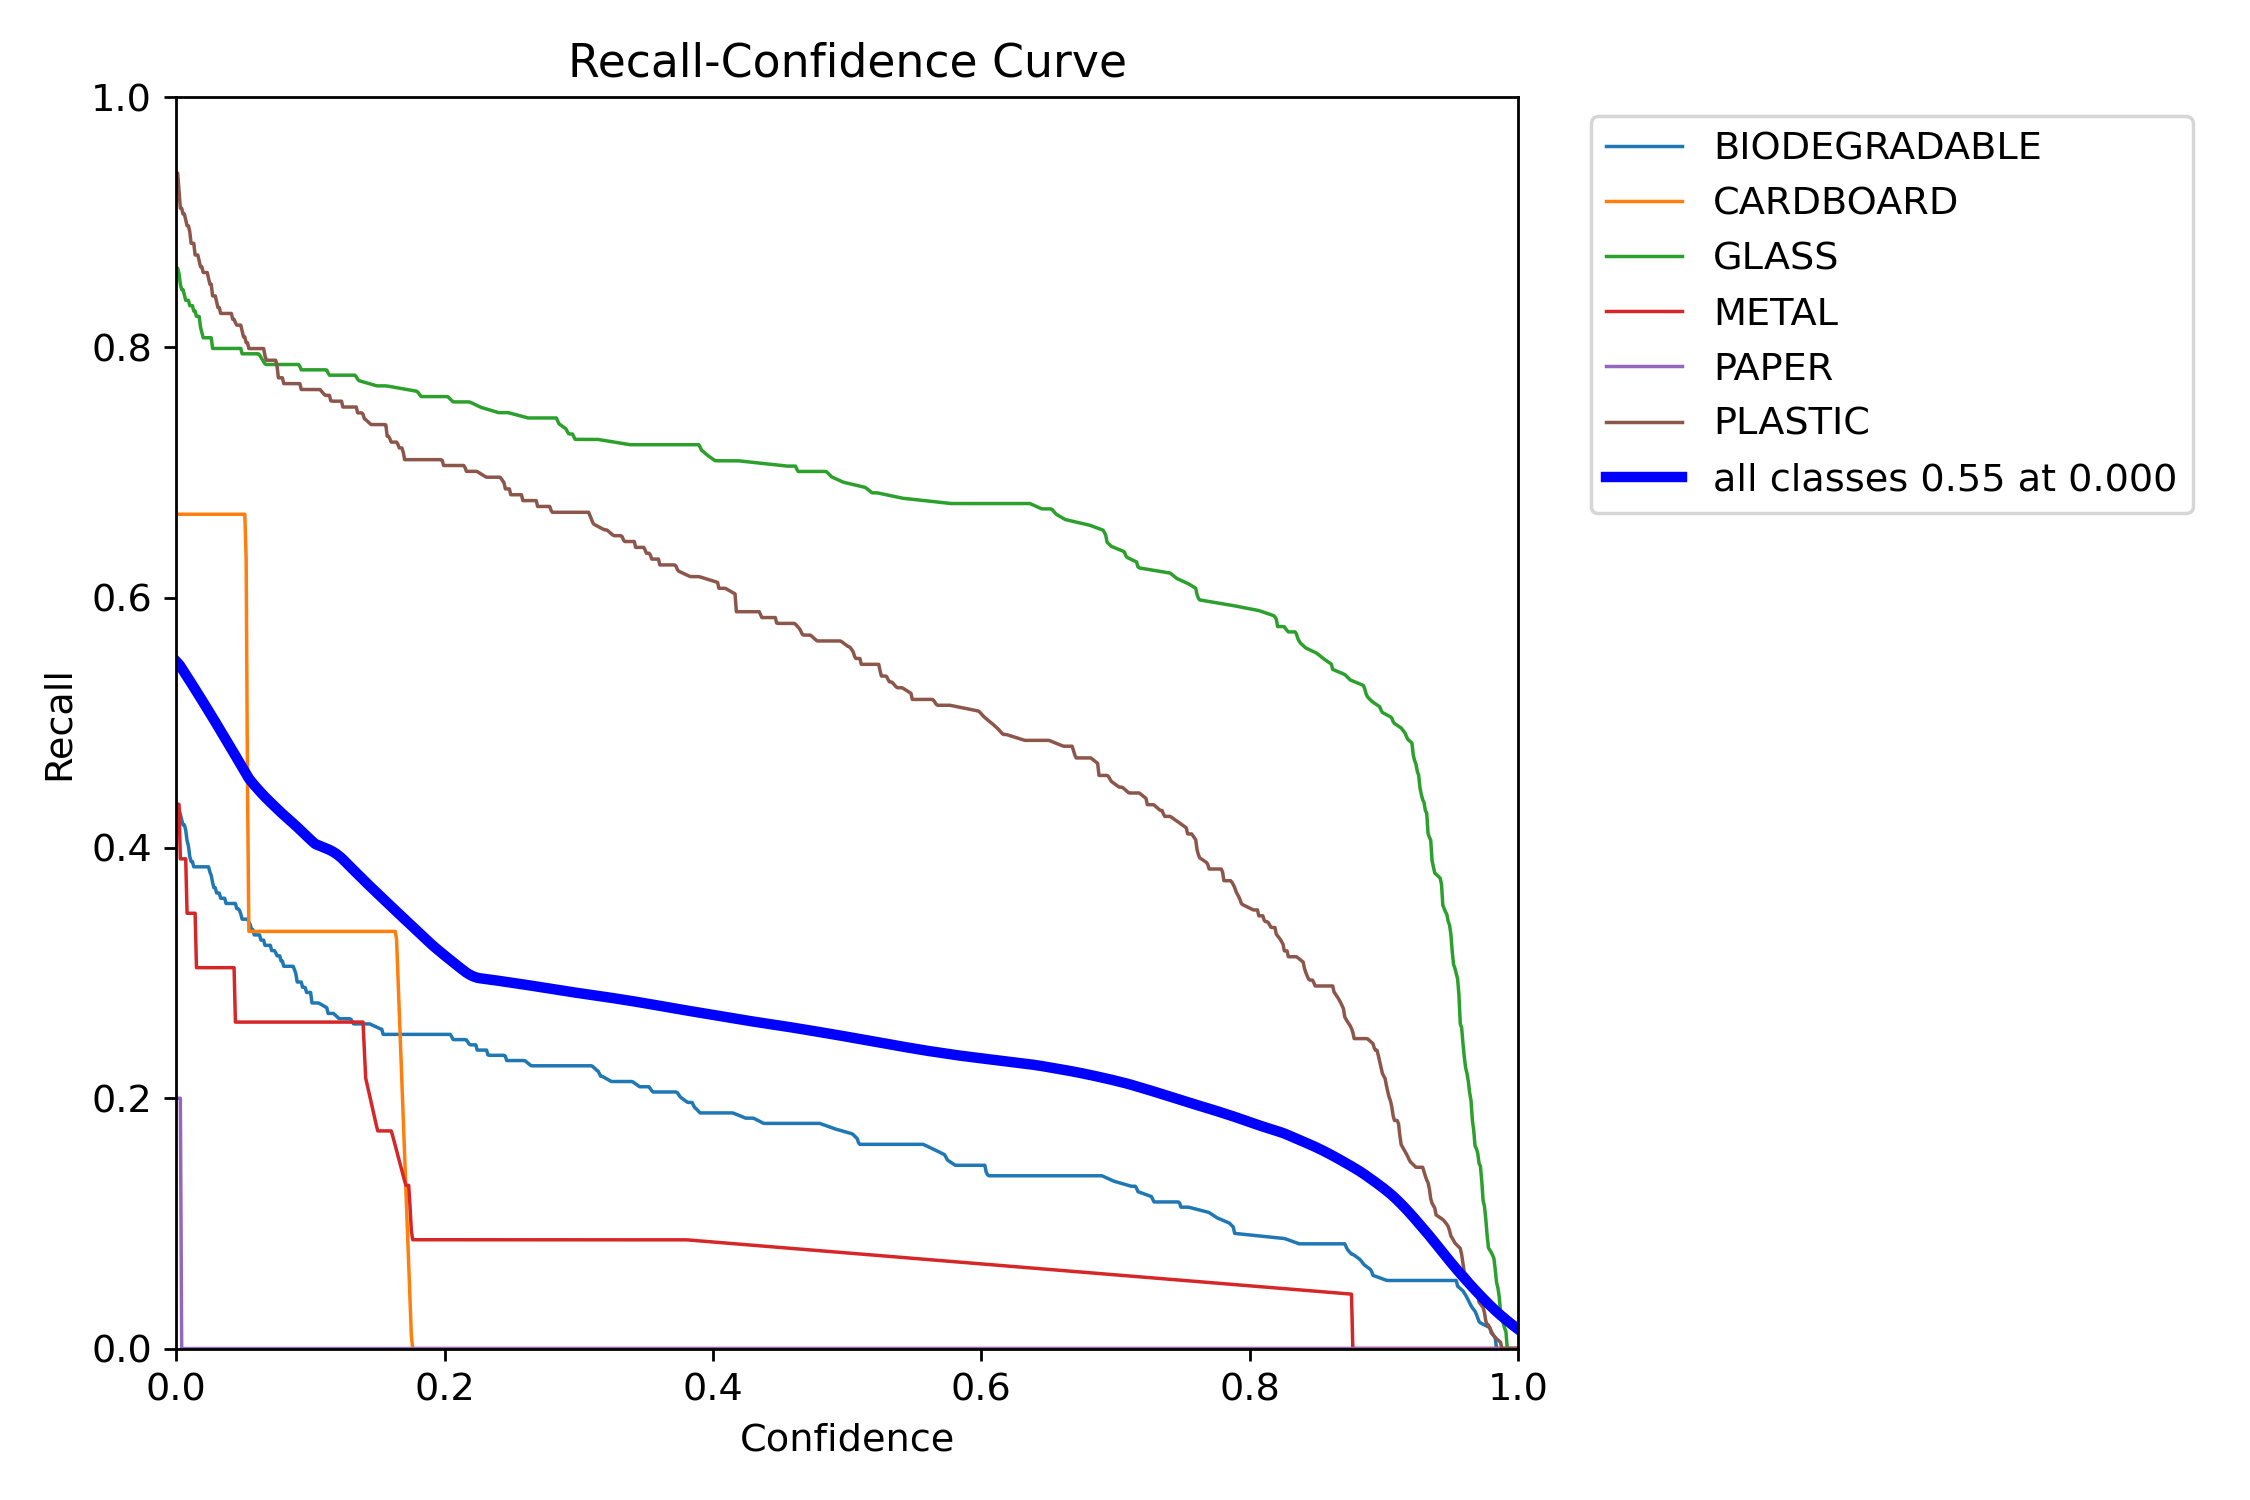

--------------------------------------------------------------------------------

Gráfico: Confusion Matrix


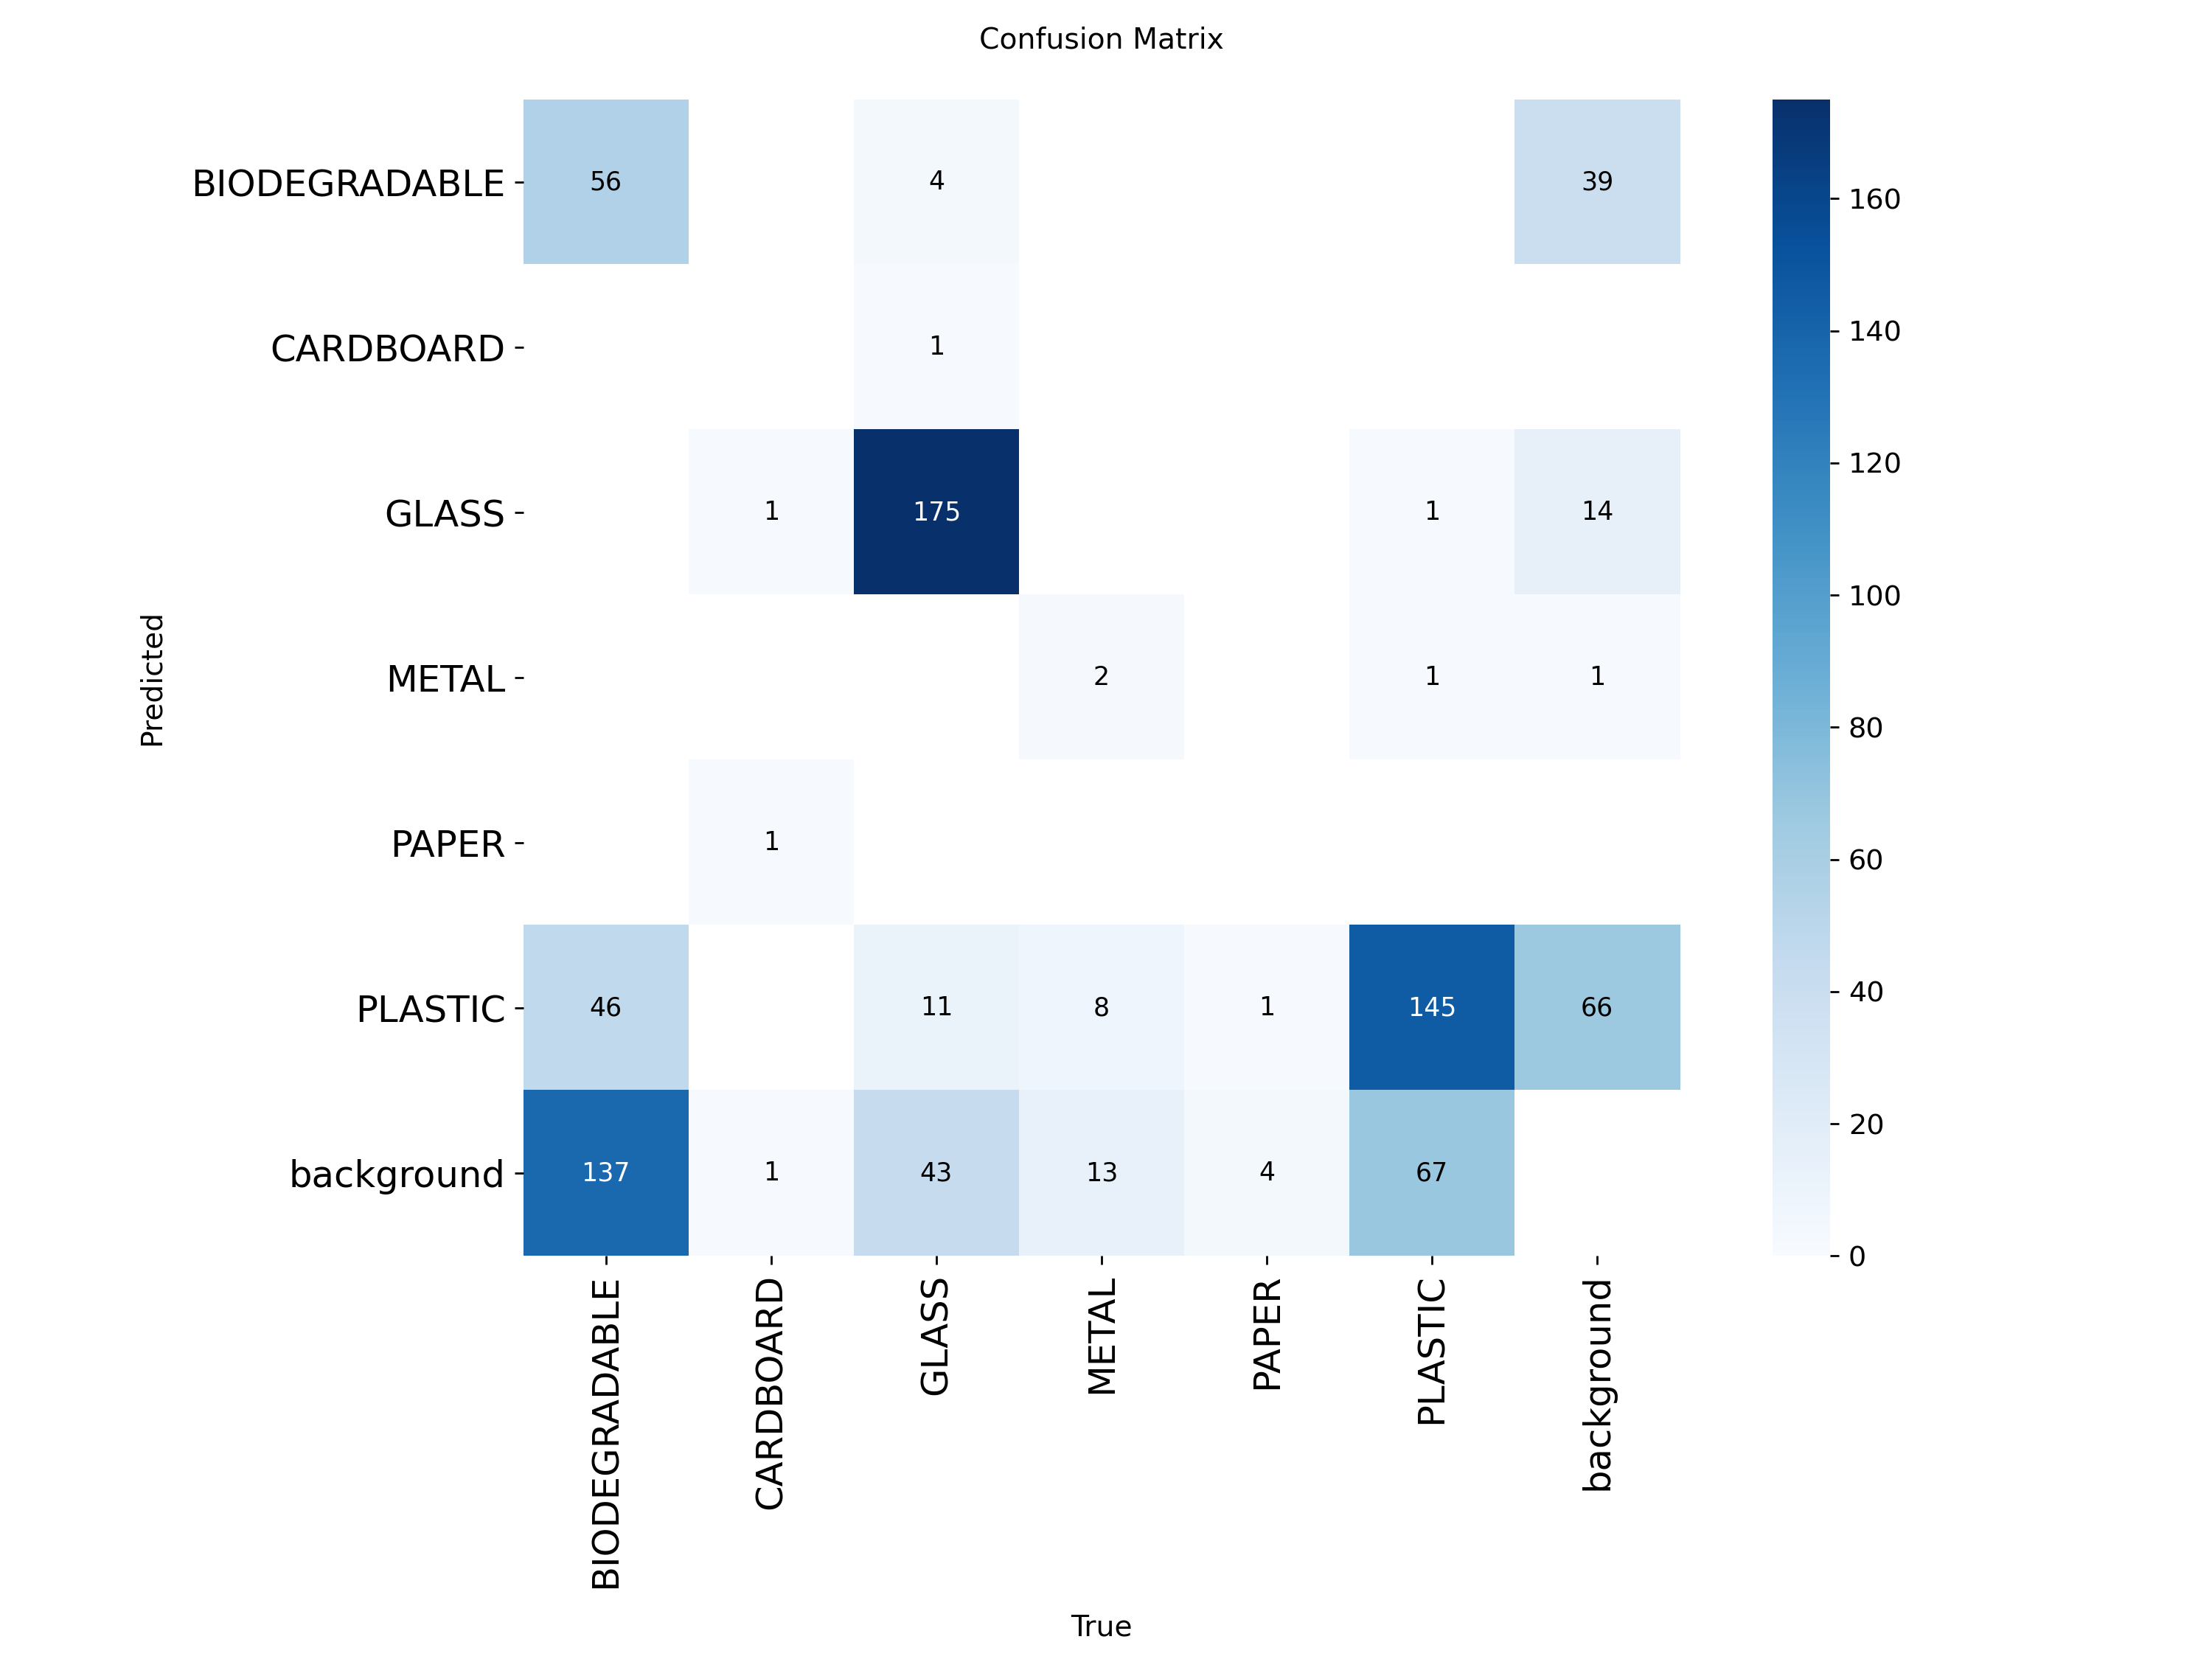

--------------------------------------------------------------------------------

Gráfico: Confusion Matrix Normalized


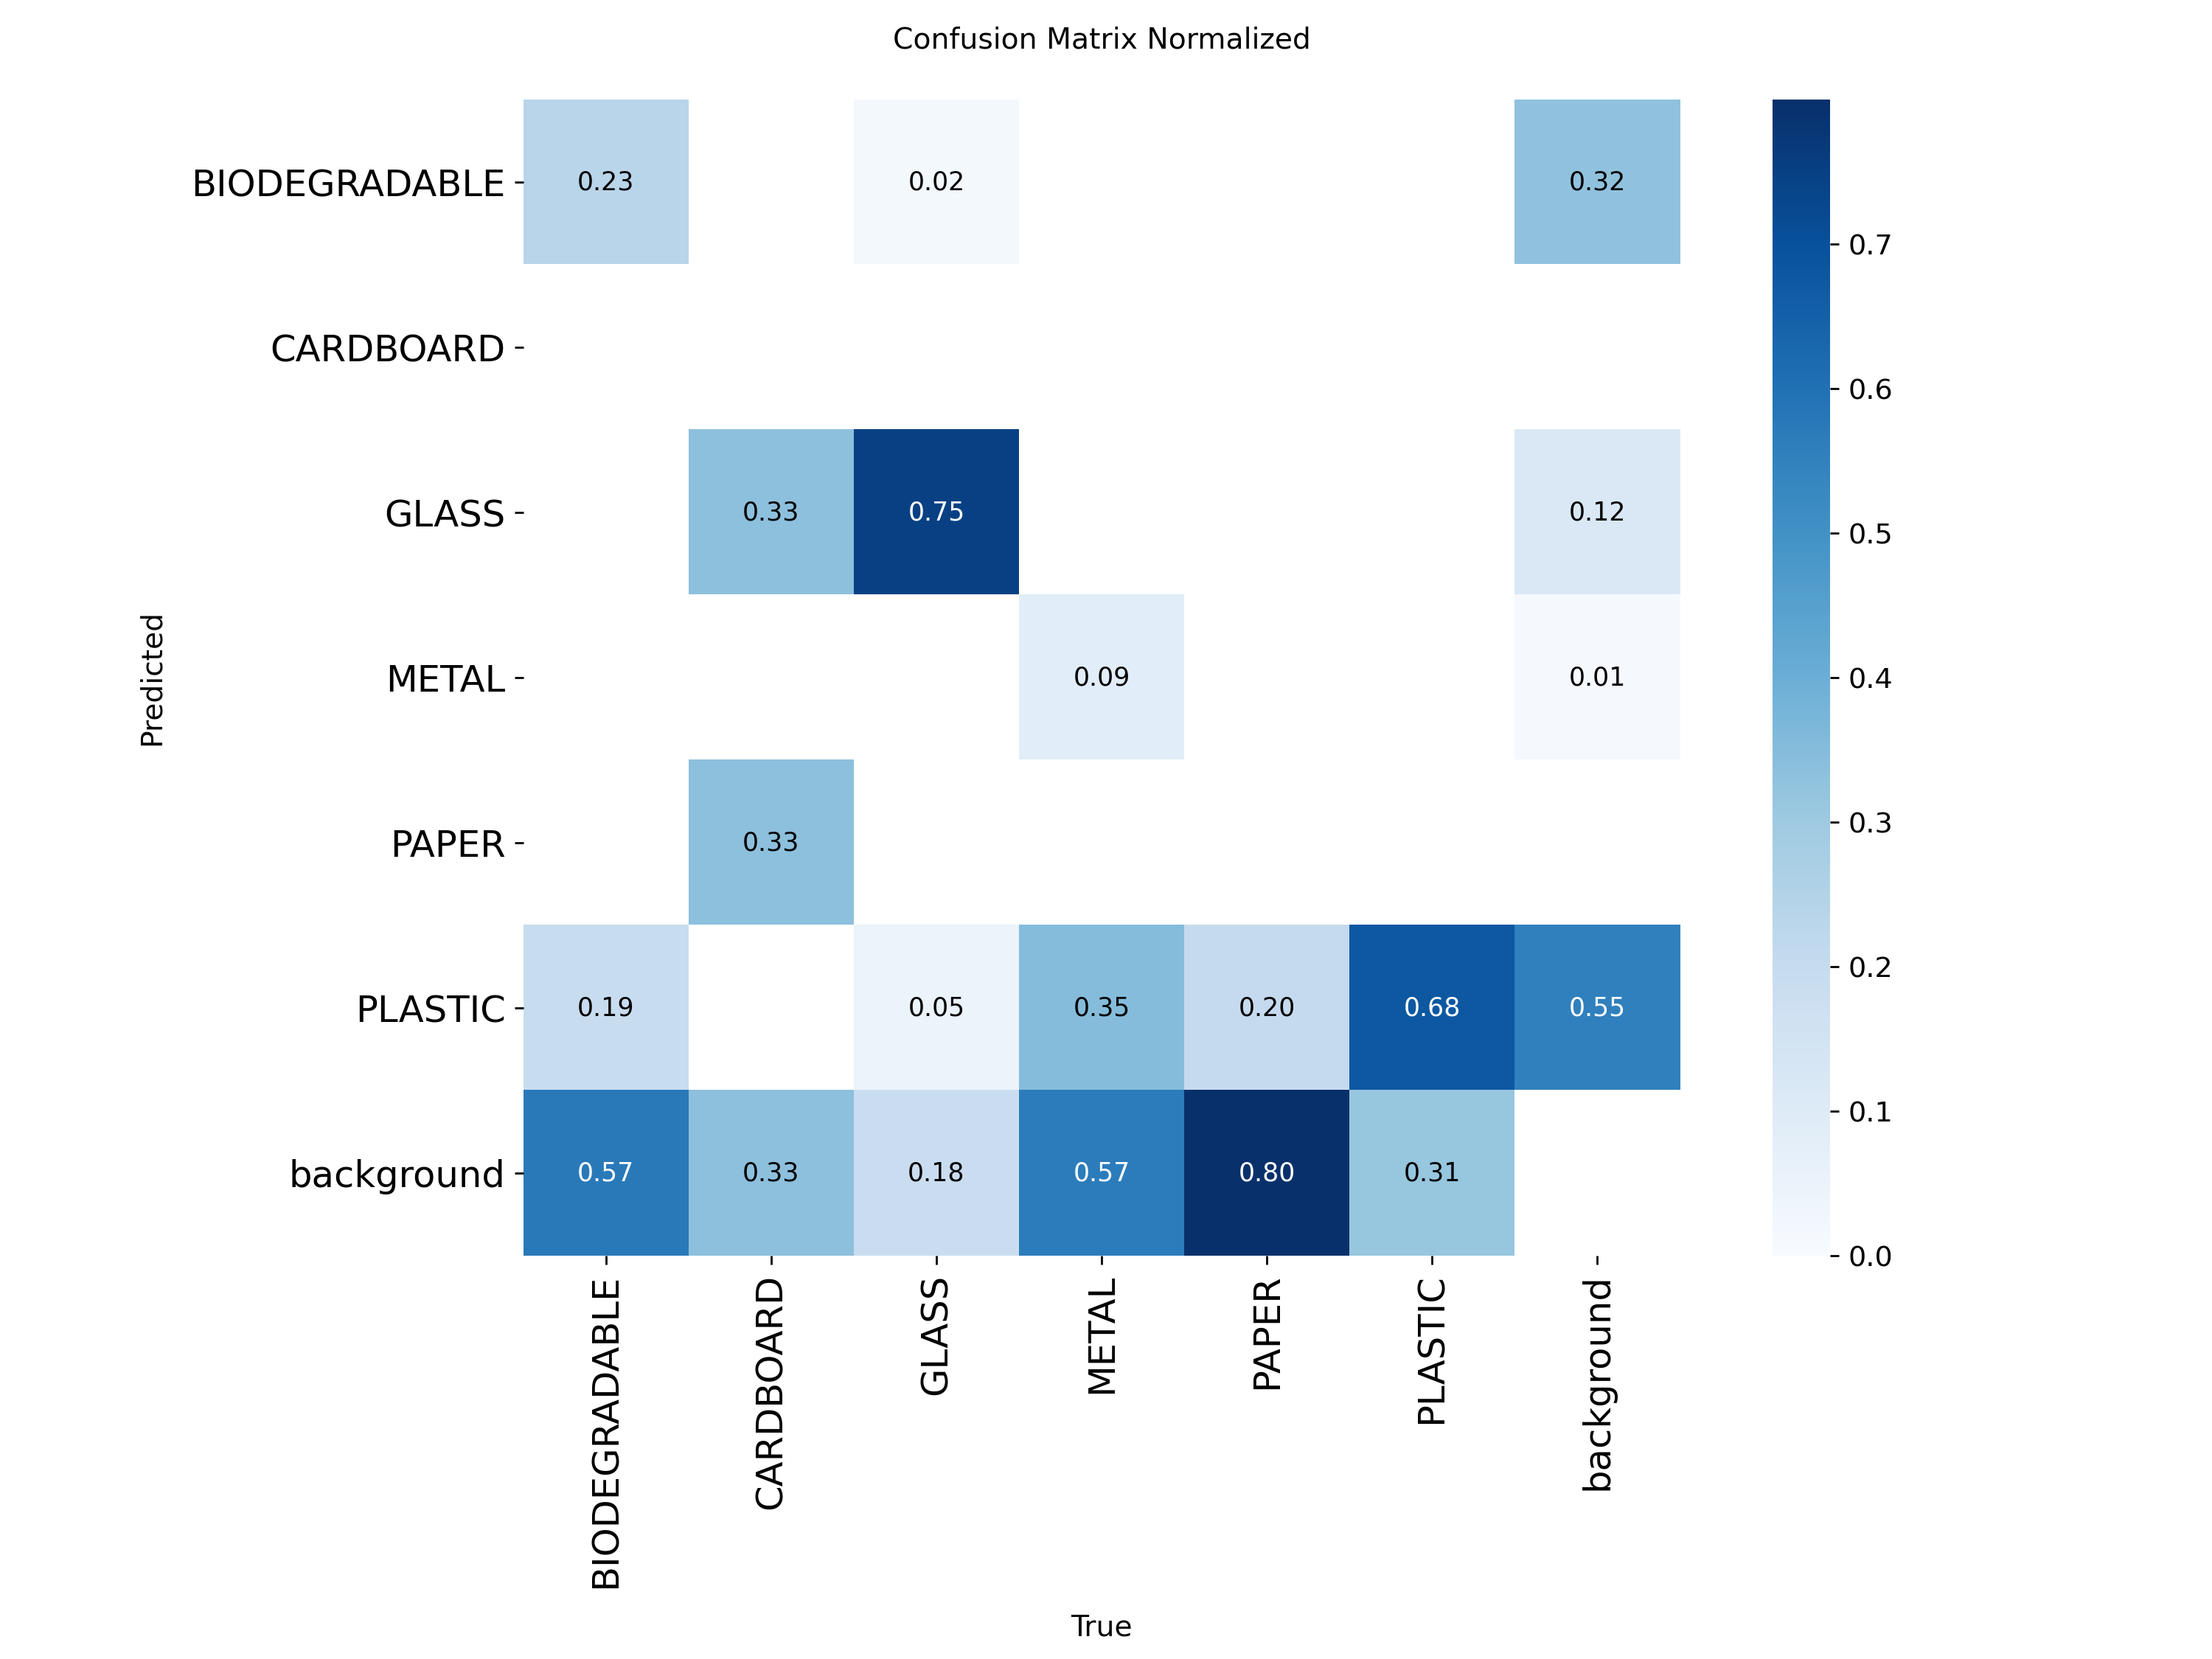

--------------------------------------------------------------------------------

Gráfico: Labels


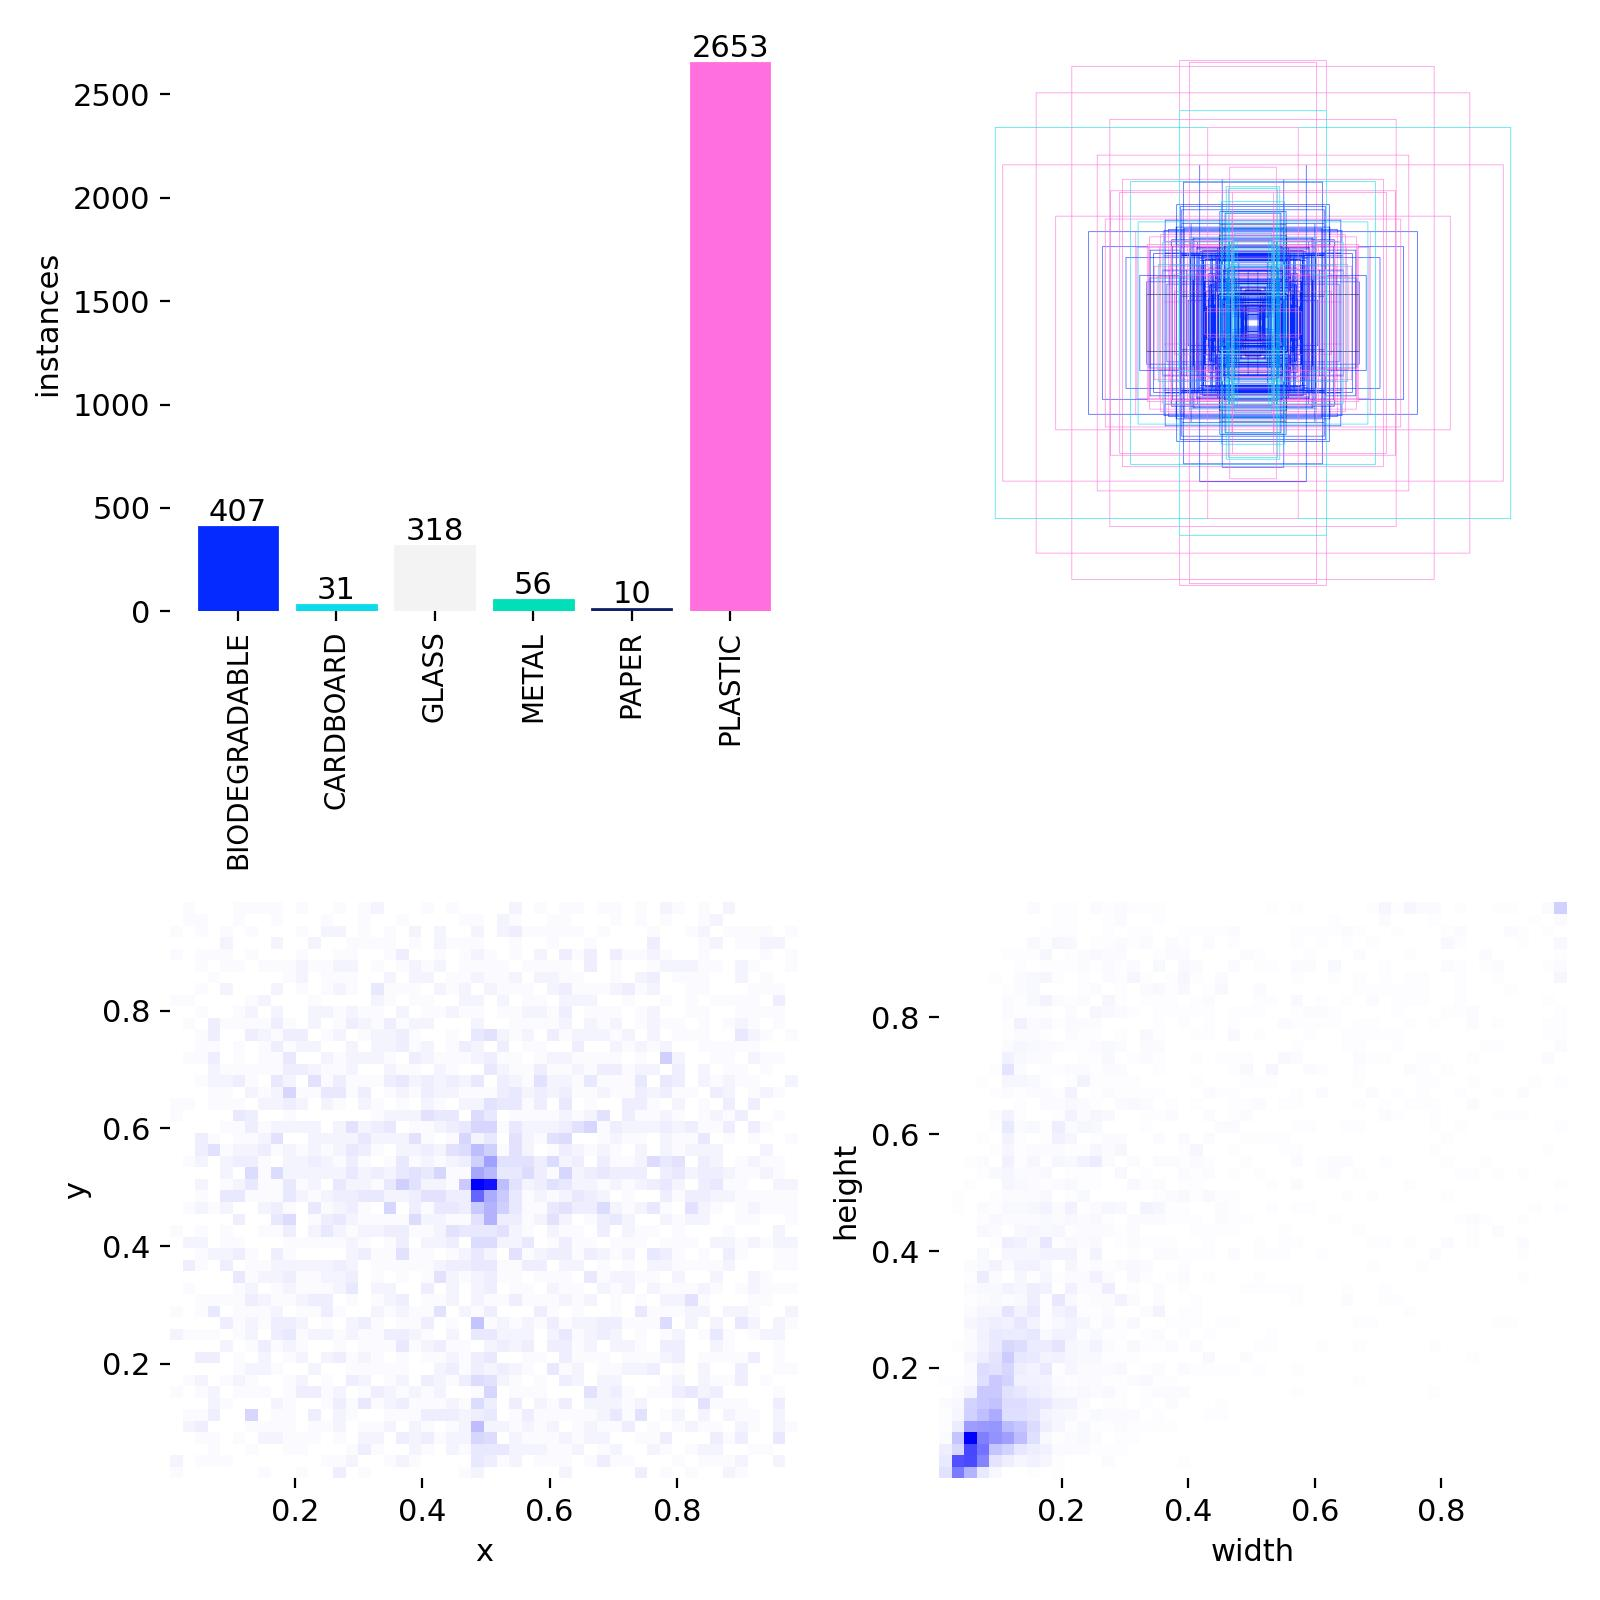

--------------------------------------------------------------------------------

Gráfico: Results


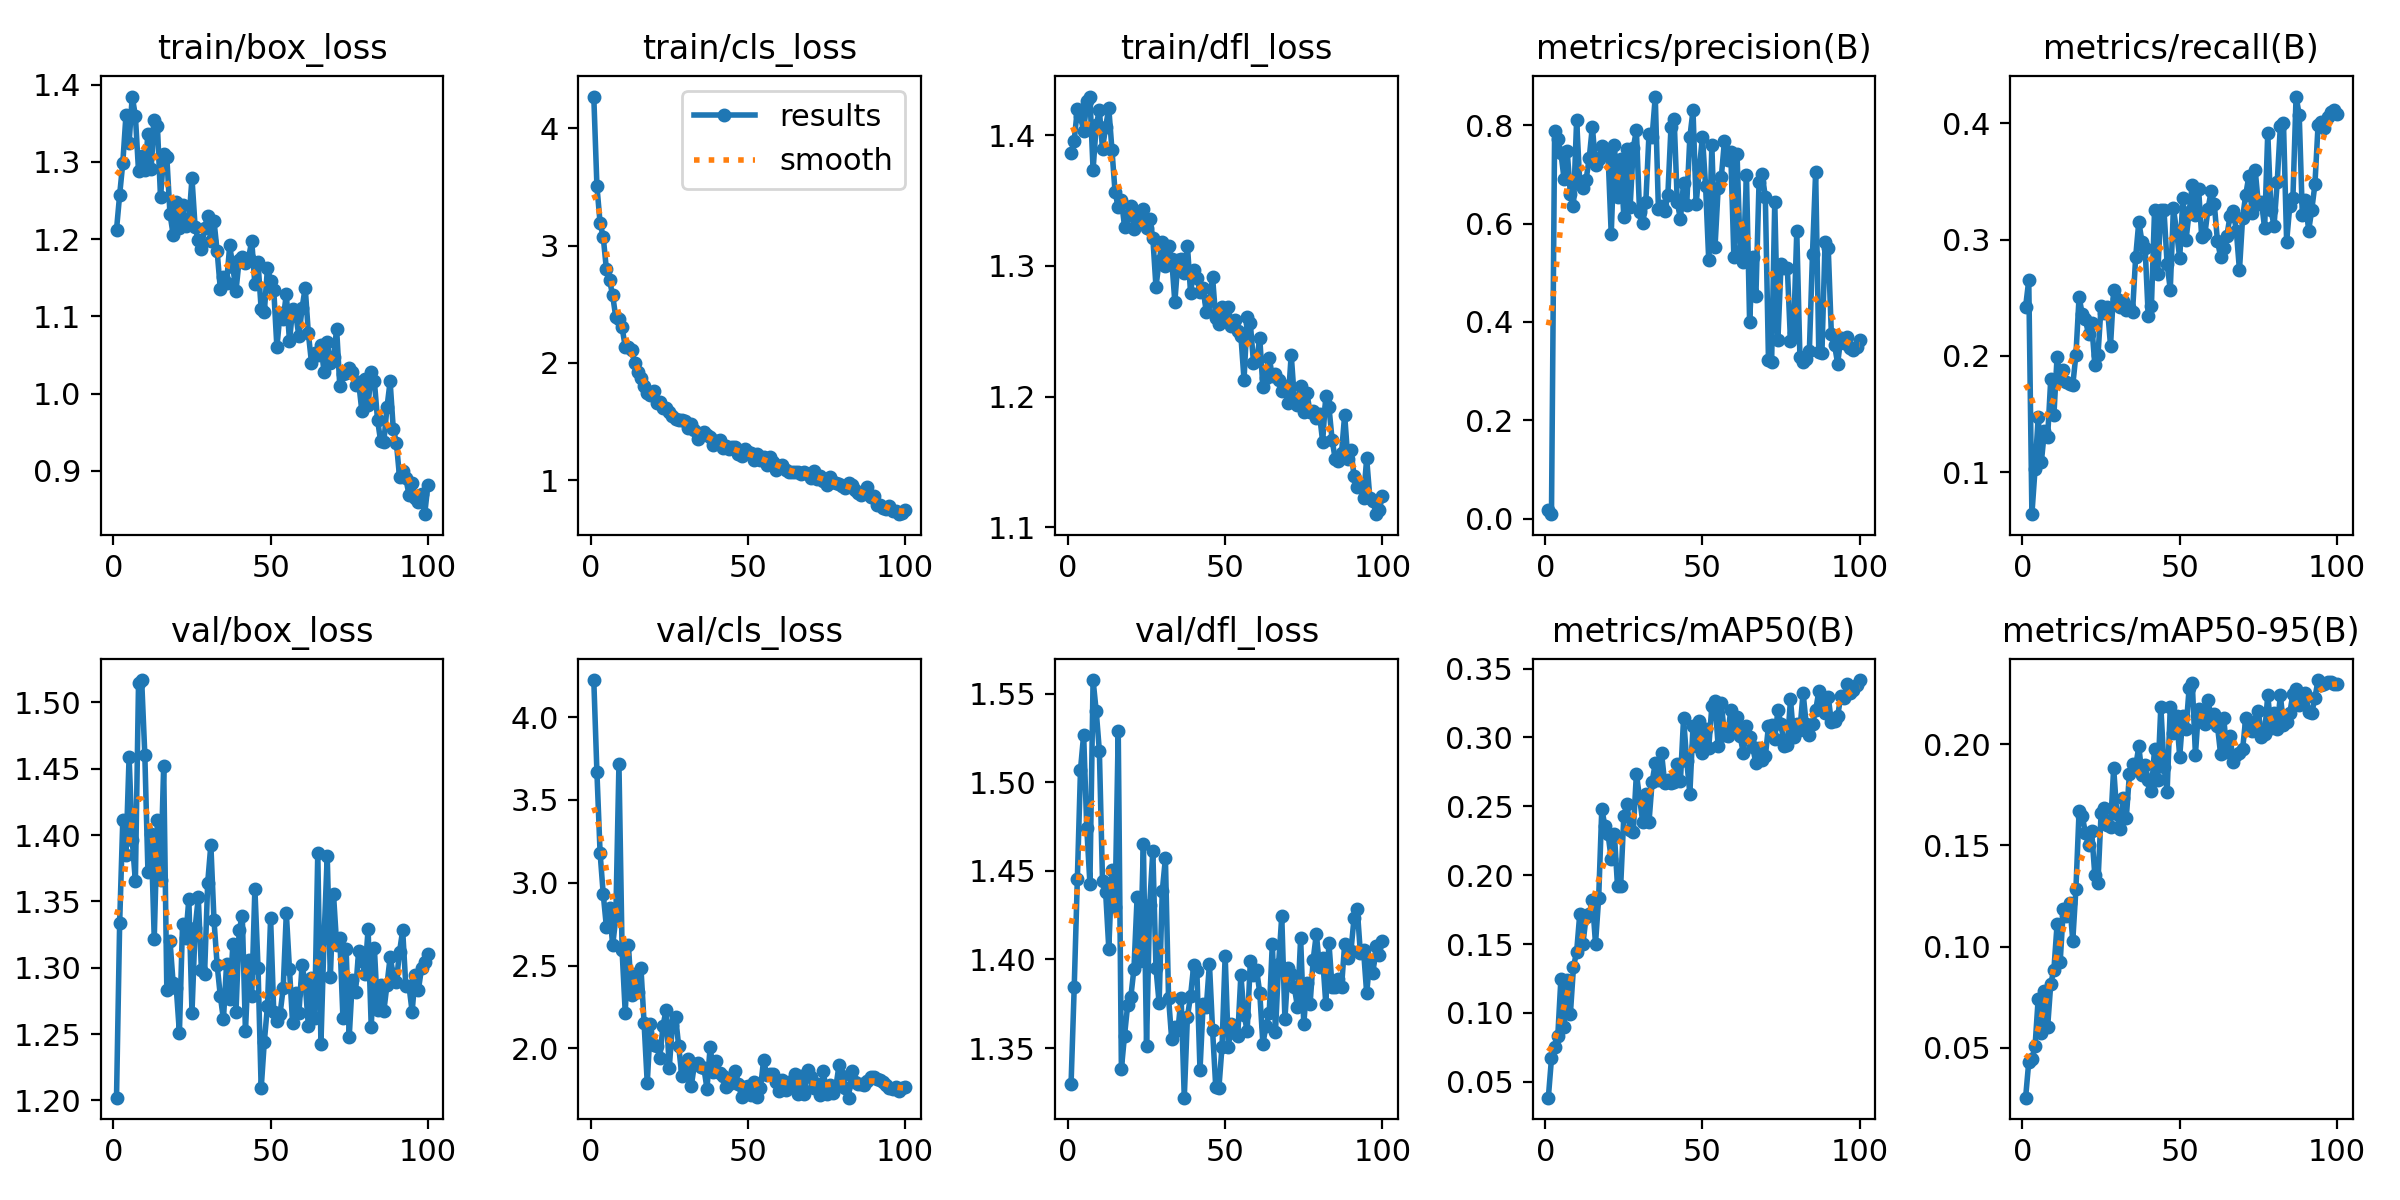

--------------------------------------------------------------------------------



In [19]:
pasta_treino = "runs/detect/Automacao_Triagem/yolov10n_esteira"

todas_imagens = glob.glob(os.path.join(pasta_treino, "*.png")) + \
                glob.glob(os.path.join(pasta_treino, "*.jpg"))

# Lógica de filtragem: ignora imagens que mostram exemplos de batches apenas, focando em gráficos de métricas e distribuições
imagens_metricas = [
    caminho for caminho in todas_imagens 
    if "val_batch" not in os.path.basename(caminho) and "train_batch" not in os.path.basename(caminho)
]

# Exibição dinâmica

print(f"Foram encontradas {len(imagens_metricas)} imagens de métricas e distribuições.\n")
print("=" * 80)

# Ordena alfabeticamente para manter a exibição padronizada
for caminho_img in sorted(imagens_metricas):
    nome_arquivo = os.path.basename(caminho_img)
    
    titulo_formatado = nome_arquivo.replace('.png', '').replace('.jpg', '').replace('_', ' ').title()
    
    print(f"Gráfico: {titulo_formatado}")
    
    display(Image(filename=caminho_img, width=1000))
    print("-" * 80 + "\n")